In [1]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
sns.set_theme()

# Exercise 1 - series 1
## <ins>Analyse du nombre de publications dans le monde entre 2000 et 2018</ins>

The objective of the exercise is mainly to manipulate data contained in tables, the analysis will therefore remain brief.

The solution is very approximative, but it is mainly about practicing with the different routines.


## 1. Load data from Excel to a table
- The routine readtable() is used to load data from a file. The routine allows different file types (.txt, .dat, .xlsx,...)
- It is also possible to use the Import Data utility found in the Home menu.
- Some columns have been identified directly by the routine as catagorical

In [2]:
df = pd.read_excel("S1/Series_DOE_1_data_scientifc_publication.xlsx", sheet_name="Data")
df[df == 0] = np.nan  # Hide empty values

The columns region is defined as categorical

In [3]:
df.Region = pd.Categorical(df.Region)
df.Code = pd.Categorical(df.Code)
df.Level = pd.Categorical(df.Level)

### Summary of the data
The summary routine produces some statistical data from a table. In this ase we have chosen a few columns to illustrate the use of this function.

In [4]:
years = [y for y in df.keys() if isinstance(y, int)]
num_countries = df.Code.size

In [5]:
display(df)
display(df.describe())

,Country,Code,Region,Income,Level,2000,2001,2002,2003,2004,...,2011,2012,2013,2014,2015,2016,2017,2018,pop2000,pop2018
0,Afghanistan,AFG,South Asia,Low income,1,4.00,1.00,4.50,8.34,5.75,...,39.62,34.15,27.81,34.69,22.20,81.64,91.89,111.72,20779957,37171922
1,Angola,AGO,Sub-Saharan Africa,Lower middle income,2,7.17,10.58,15.13,5.89,9.23,...,17.78,22.38,23.85,33.48,31.59,39.97,55.50,30.12,16395477,30809787
2,Albania,ALB,Europe & Central Asia,Upper middle income,3,22.34,18.71,24.53,23.82,17.91,...,146.82,165.75,162.65,180.39,177.80,185.87,149.54,180.36,3089027,2866376
3,Andorra,AND,Europe & Central Asia,High income,4,NaN,2.64,0.50,4.70,1.31,...,0.91,3.58,5.26,4.18,8.08,7.99,2.01,3.60,65390,77008
4,United Arab Emirates,ARE,Middle East & North Africa,High income,4,330.44,380.58,399.54,539.87,555.02,...,1421.83,1625.96,1765.77,1816.50,2294.58,2484.16,2899.67,3144.89,3134067,9630966
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,Kosovo,XKX,Europe & Central Asia,Upper middle income,3,NaN,NaN,NaN,NaN,NaN,...,106.73,113.40,123.34,122.23,136.84,187.91,261.45,278.43,1700000,1797085
192,"Yemen, Rep.",YEM,Middle East & North Africa,Low income,1,22.83,42.49,27.13,33.84,41.15,...,105.17,106.85,118.75,139.90,107.34,119.49,126.37,137.44,17409071,28498683
193,South Africa,ZAF,Sub-Saharan Africa,Upper middle income,3,3897.55,4099.38,4413.16,4267.39,4831.02,...,8293.80,9105.71,9709.05,10349.90,10964.38,12045.47,12846.08,13008.74,44967713,57792520
194,Zambia,ZMB,Sub-Saharan Africa,Lower middle income,2,33.60,51.96,61.54,47.78,42.84,...,101.03,106.12,119.47,134.46,157.23,181.66,209.45,213.07,10415942,17351714


,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2011,2012,2013,2014,2015,2016,2017,2018,pop2000,pop2018
count,185.000000,188.000000,186.000000,191.000000,190.000000,189.000000,192.000000,192.00000,192.000000,195.000000,...,195.000000,196.000000,196.000000,196.000000,196.000000,196.000000,195.000000,195.000000,1.960000e+02,1.960000e+02
mean,5679.457351,5781.611277,6095.662742,6219.749162,6837.794579,7720.627672,8005.317969,8477.20875,8932.907708,9317.842821,...,10285.861846,10541.530612,10912.195102,11365.876786,11537.092398,11961.836582,12481.151333,12948.046000,3.103755e+07,3.856408e+07
std,25480.269754,25549.970490,26721.408092,27334.978630,29774.292467,33242.336397,33889.773692,35199.06532,36548.418975,38122.448664,...,41400.612604,41817.562310,43259.234941,44939.262617,45583.287811,47044.139052,49206.901563,51714.787255,1.211710e+08,1.433553e+08
min,0.250000,0.200000,0.120000,0.090000,0.130000,0.370000,0.270000,0.37000,0.330000,0.250000,...,0.050000,0.040000,0.330000,0.160000,0.330000,0.410000,0.650000,0.620000,9.392000e+03,1.067800e+04
25%,12.140000,9.930000,12.392500,11.230000,13.740000,16.390000,17.310000,20.61250,26.717500,17.800000,...,23.870000,26.537500,29.985000,34.462500,32.550000,41.395000,48.005000,45.110000,1.377166e+06,2.037214e+06
50%,101.860000,96.310000,115.080000,120.190000,133.695000,160.340000,156.000000,173.64000,188.785000,189.880000,...,214.620000,228.525000,248.965000,250.600000,262.935000,306.715000,324.960000,359.330000,6.043663e+06,8.560326e+06
75%,1326.260000,1233.695000,1448.950000,1387.405000,1671.507500,1767.140000,1949.942500,2421.88000,2593.840000,2991.465000,...,3630.340000,3629.152500,3693.037500,3813.100000,4273.672500,4641.190000,5059.275000,5443.230000,1.918446e+07,2.819645e+07
max,304781.560000,305612.910000,319307.620000,329398.860000,353853.490000,384572.940000,385515.000000,391909.59000,393978.950000,399350.310000,...,423958.810000,427996.800000,429570.050000,433192.280000,429988.890000,438348.740000,473438.510000,528263.250000,1.262645e+09,1.392730e+09


## 2. Adding data to a table
The statement asked to connect population data. In fact they are already in the right sheet of Excel.

But the table can be merged with another table if they have the same number of rows, as in the example below:

In [6]:
table1 = pd.DataFrame.from_dict(dict(
    num=[100, 200, 300, 400],
))
table2 = pd.DataFrame.from_dict(dict(
    num=np.random.rand(4),
))
display(table1)
display(table2)
tables = pd.concat([table1, table2])
display(tables)

,num
0,100
1,200
2,300
3,400


,num
0,0.876346
1,0.192117
2,0.959044
3,0.857834


,num
0,100.000000
1,200.000000
2,300.000000
3,400.000000
0,0.876346
1,0.192117
2,0.959044
3,0.857834


## 3. Check for possible aberration in the data

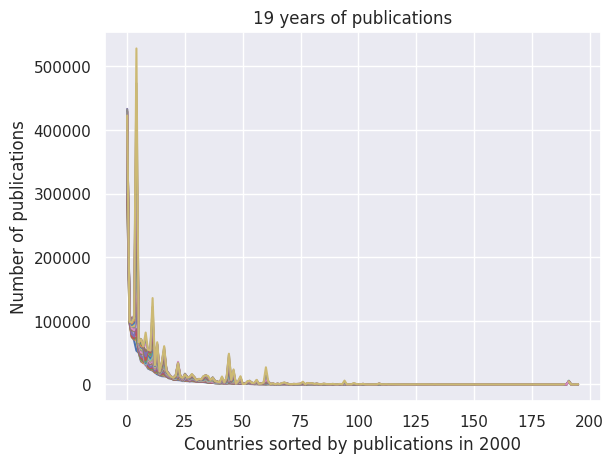

In [7]:
df = df.sort_values(2000, ascending=False)
plt.plot(np.arange(num_countries), df[years])
plt.ylabel("Number of publications")
plt.xlabel("Countries sorted by publications in 2000")
plt.title("19 years of publications")
plt.show()

In log scale for the publications :

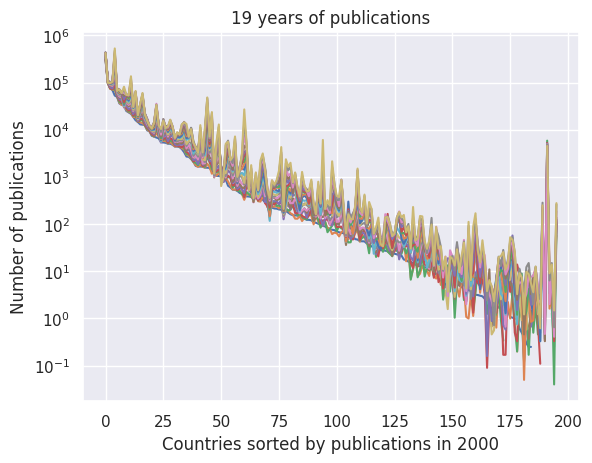

In [8]:
plt.plot(np.arange(num_countries), df[years])
plt.semilogy()
plt.ylabel("Number of publications")
plt.xlabel("Countries sorted by publications in 2000")
plt.title("19 years of publications")
plt.show()

Looking year by year

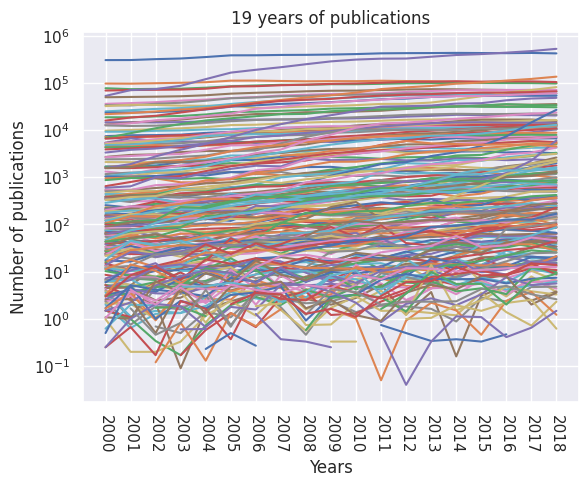

In [9]:
plt.plot(years, df[years].T)
plt.semilogy()
plt.ylabel("Number of publications")
plt.xlabel("Years")
plt.title("19 years of publications")
plt.xticks(years, rotation=270)
plt.show()

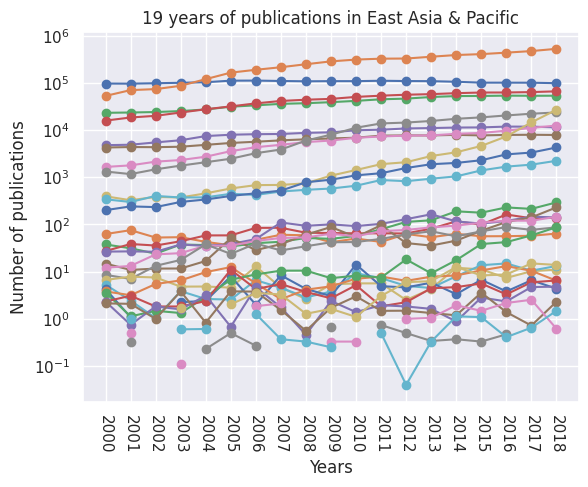

In [10]:
plt.plot(years, df[years][df["Region"]=="East Asia & Pacific"].T, "-o")
plt.semilogy()
plt.ylabel("Number of publications")
plt.xlabel("Years")
plt.title("19 years of publications in East Asia & Pacific")
plt.xticks(years, rotation=270)
plt.show()

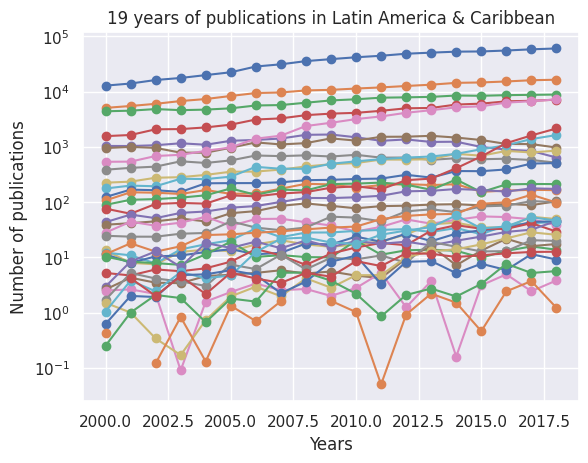

In [11]:
plt.plot(years, df[years][df["Region"]=="Latin America & Caribbean"].T, "-o")
plt.semilogy()
plt.ylabel("Number of publications")
plt.xlabel("Years")
plt.title("19 years of publications in Latin America & Caribbean")
plt.show()

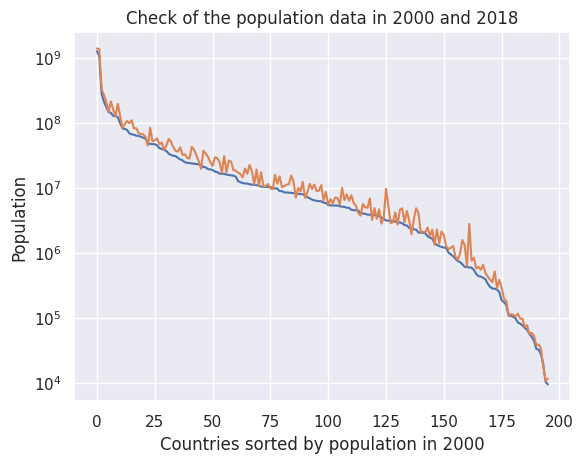

In [12]:
df = df.sort_values("pop2000", ascending=False)
plt.plot(np.arange(num_countries), df["pop2000"])
plt.plot(np.arange(num_countries), df["pop2018"])
plt.semilogy()
plt.ylabel("Population")
plt.xlabel("Countries sorted by population in 2000")
plt.title("Check of the population data in 2000 and 2018")
plt.show()

Some population increases seem huge. Let's check the relative change
$$R_P = \frac{P_{2018} - P_{2000}}{P_{2000}}$$

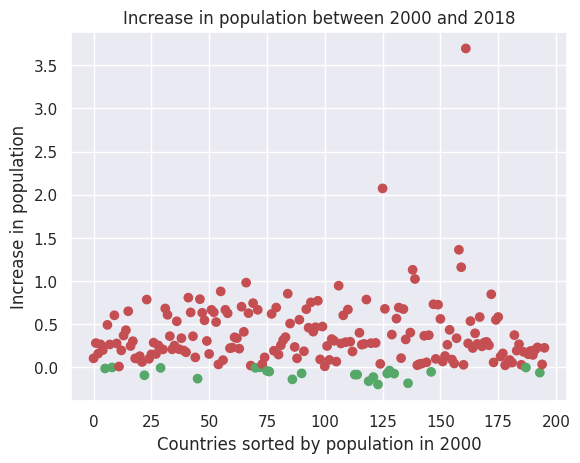

In [13]:
df["Rp"] = (df["pop2018"]-df["pop2000"])/df["pop2000"]
plt.scatter(np.arange(num_countries), df.Rp, color=np.where(df.Rp>0, "r", "g"))
plt.xlabel("Countries sorted by population in 2000")
plt.ylabel("Increase in population")
plt.title("Increase in population between 2000 and 2018")
plt.show()

Some countries (in green) have a decrease in population. The minimum is -20% for 

In [14]:
df = df.sort_values("pop2000")
print(df.Rp.argmin())
print(df.Country.iloc[df.Rp.argmin()])
print(df.pop2018.iloc[df.Rp.argmin()])
print(f"{df.Rp.min():.0%}")

72
Lithuania
2801543
-20%


Some countries (in red) have a huge increase in their population. The maximun is 370% for

In [15]:
print(df.Rp.argmax())
print(df.Country.iloc[df.Rp.argmax()])
print(df.pop2018.iloc[df.Rp.argmax()])
print(f"{df.Rp.max():.0%}")

34
Qatar
2781682
370%


A small tool to see the country coresponding to a point in the graphic.

In [16]:
from ipywidgets import interact, IntSlider
i = interact(
    lambda i: print(f"{df.Country.iloc[i]}: {df.pop2000.iloc[i]}, {df.pop2018.iloc[i]}, {df.Rp.iloc[i]}"),
    i=IntSlider(min=0, max=num_countries-1, step=1, value=0),
)

interactive(children=(IntSlider(value=0, description='i', max=195), Output()), _dom_classes=('widget-interact'…

## 4. Definition of categories
In fact the categories have been defined in the first step when loading the data. 
The columns region is defined as categorical just after the nload of the data.

## 5. Aggregation of data by categories
A new table called data_Asia is made with the data agragated by level of income.

In [17]:
df["GroupCount"] = 1
df_Asia = df[df.Region=="East Asia & Pacific"].copy()
df_Asia = df_Asia.groupby("Income").sum(numeric_only=True)
df_Asia[["GroupCount", 2000]]

,GroupCount,2000
Income,,
High income,8,145344.10
Low income,1,3.61
Lower middle income,14,1083.72
Upper middle income,7,56081.71


In [18]:
df_Asia["r2000"] = df_Asia[2000] / df_Asia["pop2000"]
df_Asia["r2018"] = df_Asia[2018] / df_Asia["pop2018"]
display(df_Asia[[2000, 2018, "pop2000", "pop2018", "r2000", "r2018"]])

,2000,2018,pop2000,pop2018,r2000,r2018
Income,,,,,,
High income,145344.10,238426.69,201252303,214115246,7.221984e-04,0.001114
Low income,3.61,87.42,22929078,25549606,1.574420e-07,0.000003
Lower middle income,1083.72,34189.27,443707896,561302167,2.442418e-06,0.000061
Upper middle income,56081.71,564586.72,1349761010,1494743093,4.154936e-05,0.000378


## 6. Bubble plot size of the population vs the number of publications by regions

### Statistics per category

In [19]:
summary = df[["Region"]].copy()
summary = summary.groupby("Region", observed=True).sum().rename(columns=dict(pop2000="pop2000_mean"))
grp = df[["Region", "pop2000"]].groupby("Region", observed=True)
for attr in "sum min mean max std".split():
    # summary["attr"] = df[["Region", "pop2000"]].groupby("Region").attr().values
    summary[f"pop2000_{attr}"] = getattr(grp, attr)().values
display(summary)

,pop2000_sum,pop2000_min,pop2000_mean,pop2000_max,pop2000_std
Region,,,,,
East Asia & Pacific,2017650287,9392,6.725501e+07,1262645000,2.305844e+08
Europe & Central Asia,860975344,27460,1.594399e+07,146596869,2.656018e+07
Latin America & Caribbean,520427863,44083,1.530670e+07,174790339,3.377414e+07
Middle East & North Africa,315326781,390087,1.501556e+07,68831561,1.985735e+07
North America,312848141,30685730,1.564241e+08,282162411,1.778209e+08
South Asia,1390946065,279396,1.738683e+08,1056575548,3.610356e+08
Sub-Saharan Africa,665185324,81131,1.415288e+07,122283853,2.120932e+07


### Statistics of the population vs. the number of publications by regions

In [20]:
summary_2000 = df[["Region", "GroupCount", 2000, "pop2000"]].groupby("Region", observed=True).sum()
display(summary_2000)

,GroupCount,2000,pop2000
Region,,,
East Asia & Pacific,30,202513.14,2017650287
Europe & Central Asia,54,431619.12,860975344
Latin America & Caribbean,34,27688.74,520427863
Middle East & North Africa,21,19484.24,315326781
North America,2,338635.95,312848141
South Asia,8,23565.15,1390946065
Sub-Saharan Africa,47,7193.27,665185324


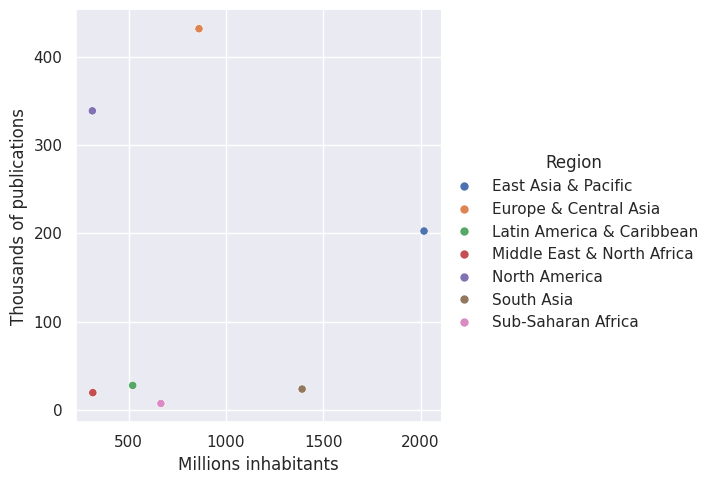

In [21]:
sns.relplot(data=summary_2000, x=summary_2000["pop2000"]/1e6, y=summary_2000[2000]/1e3, hue="Region")
plt.xlabel("Millions inhabitants")
plt.ylabel("Thousands of publications")
plt.show()

## 7. Graphics per categories

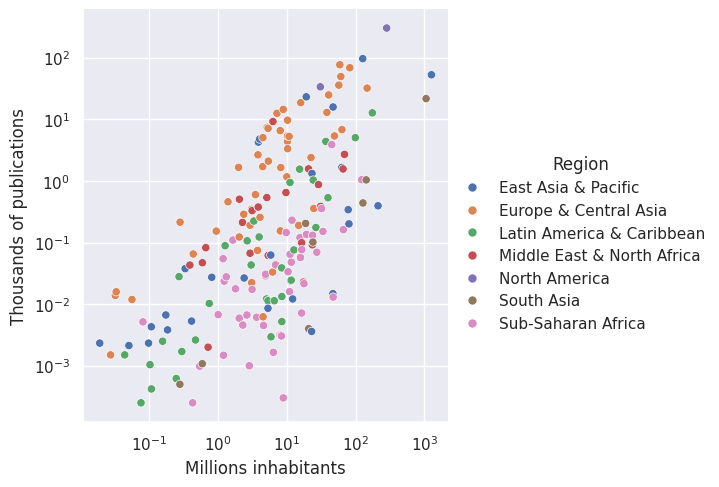

In [22]:
sns.relplot(data=df, x=df["pop2000"]/1e6, y=df[2000]/1e3, hue="Region")
plt.xlabel("Millions inhabitants")
plt.ylabel("Thousands of publications")
plt.loglog()
plt.show()

## 8. Boxplots

The box-plot is an interesting tool for comparing subgroups. As an example, the relative increase of publications between 2000 and 2018:

In [23]:
df["r2000"] = df[2000] / df["pop2000"]
df["r2018"] = df[2018] / df["pop2018"]
display(df[["r2000", "r2018"]])

,r2000,r2018
179,NaN,0.000129
132,NaN,NaN
139,0.000122,0.000363
158,0.000055,0.000320
108,0.000431,0.001166
...,...,...
23,0.000073,0.000287
77,0.000002,0.000101
184,0.001080,0.001294
78,0.000021,0.000100


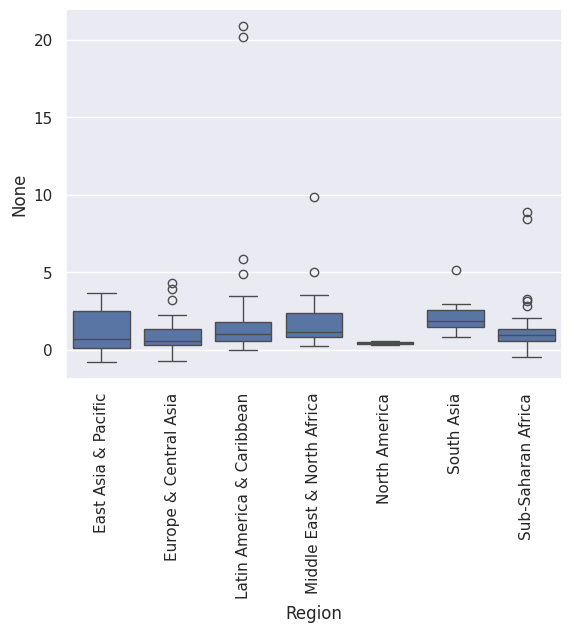

In [24]:
sns.boxplot(x=df["Region"], y=(df[2008] - df[2000])/df[2000])
plt.xticks(rotation=90)
#plt.semilogy()
plt.show()

In one glimpse it is possible to observe that each region has its own dynamics.
- East Asia and Pacific has a dynamic with a quite uniform trend, but not symetric. Some countries advancing more than others, 
- Europe and central Asia shows a symetrical behaviour with two countries advancing clearly more than the rest of the group
- Latin America & Caribean shows a similar behaviour with a higher avearage of increase and one couple of countries havih a rate of 5, and an other couple with an increase of 20. Evidently this correspponds to data to be checked before making any assumption on this changes
- A last comment on this graph with the situation in North America that show a clear stability

## 9. Pareto plots

Let's consider the publication in 2018 and produce a Pareto type diagram. 

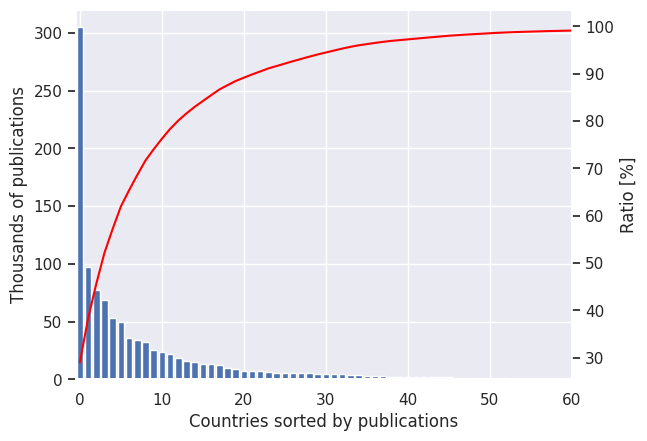

23 => 12%


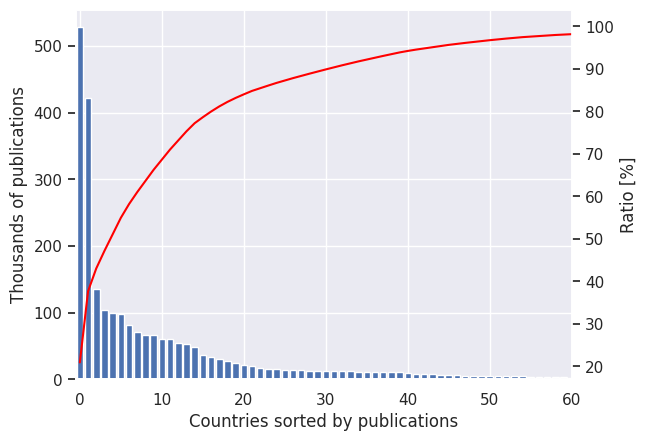

32 => 16%


In [25]:
def pareto(y):
    dfs = df.sort_values(y, ascending=False)
    n = dfs[y].size
    fig, ax = plt.subplots()
    ax2 = ax.twinx()
    ax2.sharex(ax)

    ax.bar(x=np.arange(n), height=dfs[y]/1e3)
    p = np.cumsum(dfs[y])/dfs[y].sum()*100
    ax2.plot(np.arange(n), p, c="red")

    ax2.grid(False)
    ax.set_xlim(-0.5, 60)
    ax.set_xlabel("Countries sorted by publications")
    ax.set_ylabel("Thousands of publications")
    ax2.set_ylabel("Ratio [%]")
    plt.show()

    n_90 = (p>90).argmax() + 1
    print(f"{n_90} => {n_90/num_countries:.0%}")

pareto(2000)
pareto(2018)

We can observe that 32 countries, (16% of the registrated countries) concentrate 90% of the publication in 2018. (23 countries, 11% in 2000)